In [7]:
import os
import copy
import numpy as np
import pandas as pd
import geopandas as gpd

from pathlib import Path

from src import utils, stats_utils
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=1.25)

from src.data.lfs import EulfsDs

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
config_paths = "paths_config.yml"
config_data = "data_config.yml"

In [38]:
eulfs = EulfsDs(fn_config_path=config_paths, fn_config_data=config_data)

In [48]:
eulfs.occupation_metadata_agg_subset.loc[:, ["share_green_esco_mean",
                                      "share_brown_esco_mean",
                                             "share_neutral_esco_mean"]].sum(axis=1)

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
120    1.0
121    1.0
122    1.0
123    1.0
124    1.0
Length: 125, dtype: float64

In [49]:
eulfs.occupation_metadata_agg_subset.columns

Index(['isco_level_3', 'share_green_gtp_mean', 'share_green_gtp_std',
       'share_green_gtp_median', 'share_green_gtp_iqr', 'n_occ_esco_sum',
       'share_green_esco_mean', 'share_green_esco_std',
       'share_green_esco_median', 'share_green_esco_iqr',
       'share_brown_esco_mean', 'share_brown_esco_std',
       'share_brown_esco_median', 'share_brown_esco_iqr',
       'share_neutral_esco_mean', 'share_neutral_esco_std',
       'share_neutral_esco_median', 'share_neutral_esco_iqr'],
      dtype='object')

In [10]:
df_all = eulfs.read(year=2019)

In [15]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1597861 entries, 0 to 1597860
Data columns (total 56 columns):
 #   Column                           Non-Null Count    Dtype   
---  ------                           --------------    -----   
 0   SEX                              1597861 non-null  category
 1   WSTATOR                          1597861 non-null  category
 2   NACE1D                           1594992 non-null  object  
 3   ISCO3D                           1597861 non-null  int32   
 4   COUNTRYW                         1597861 non-null  category
 5   REGIONW                          1597861 non-null  category
 6   FTPT                             1597778 non-null  category
 7   REFYEAR                          1597861 non-null  category
 8   COUNTRY                          1597861 non-null  category
 9   REGION                           1597861 non-null  category
 10  DEGURBA                          1597861 non-null  category
 11  HHTYPE                           1597

In [135]:
fpath_fr = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\FR_YEAR_1998_onwards\FR2019_y.csv"
fpath_de = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\DE_YEAR_1998_onwards\DE2019_y.csv"
fpath_pl = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\PL_YEAR_1998_onwards\PL2019_y.csv"

In [176]:
na_values = {
    "WSTATOR": ["9"],
    "SEX": ["9"],
    "NACE1D": ["9"],
    "ISCO3D": ["999"],
    "COUNTRYW": ["99"],
    "REGIONW": ["00", "99"],
    "FTPT": ["9"],
    "REFYEAR": ["9999"],
    "COUNTRY": ["99"],
    "REGION": ["00"],
    "ILOSTAT": ["9"],
    "EDUC4WN": ["9"],
    "HATLEV1D": ["9"],
    "MAINSTAT": ["9"],
    "INCDECIL": ["99"]
}

dtypes_numerical = {
    "WSTATOR": "int",
    "SEX": "int",
    "NACE1D": "str",
    "ISCO3D": "int",
    "COUNTRYW": "str",
    "REGIONW": "str",
    "FTPT": "int",
    "REFYEAR": "int",
    "COUNTRY": "str",
    "REGION": "str",
    "DEGURBA": "int",
    "HHTYPE": "int",
    "AGE": "int",
    "ILOSTAT": "int",
    "EDUC4WN": "int",
    "HATLEV1D": "int",
    "MAINSTAT": "category",
    "INCDECIL": "int",
    "COEFF": "float"
  }
dtypes_categorical = {
    "WSTATOR": "category",
    "SEX": "category",
    "NACE1D": "category",
    "ISCO3D": "category",
    "COUNTRYW": "category",
    "REGIONW": "category",
    "FTPT": "category",
    "REFYEAR": "category",
    "COUNTRY": "category",
    "REGION": "category",
    "DEGURBA": "category",
    "HHTYPE": "category",
    "AGE": "category",
    "ILOSTAT": "category",
    "EDUC4WN": "category",
    "HATLEV1D": "category",
    "MAINSTAT": "category",
    "INCDECIL": "category",
    "COEFF": "float"
}

variables = [
    "WSTATOR", "SEX", "NACE1D", "ISCO3D", "COUNTRYW", "REGIONW", "FTPT", "REFYEAR",
    "COUNTRY", "REGION", "DEGURBA", "HHTYPE", "AGE", "ILOSTAT", "EDUC4WN", "HATLEV1D",
    "MAINSTAT", "INCDECIL", "COEFF"
  ]

In [192]:
list_of_dfs = []

for fpath in [fpath_pl, fpath_de, fpath_fr]:
    df_cy = pd.read_csv(
        fpath,
        usecols=variables,
        na_values=na_values,
        dtype=dtypes_categorical,
        # converters={
        #     "COEFF": lambda x: float(x) * 1000 if x != "" else np.nan
        # },
    )

    list_of_dfs.append(df_cy)

In [195]:
df_merged = pd.concat(list_of_dfs, axis=0).reset_index(drop=True)

In [208]:
# TODO: fix SettingWithCopyWarning
for col_name in df_merged.columns:
    if pd.api.types.is_categorical_dtype(df_merged[col_name]):
        df_merged.loc[:, col_name] = df_merged.loc[
                                  :, col_name
                                  ].cat.remove_unused_categories()

In [209]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1288344 entries, 0 to 1288343
Data columns (total 19 columns):
 #   Column    Non-Null Count    Dtype   
---  ------    --------------    -----   
 0   SEX       1288344 non-null  category
 1   WSTATOR   1089722 non-null  object  
 2   NACE1D    557494 non-null   category
 3   ISCO3D    558987 non-null   object  
 4   COUNTRYW  560859 non-null   object  
 5   REGIONW   551057 non-null   object  
 6   FTPT      560879 non-null   category
 7   REFYEAR   1288344 non-null  category
 8   COUNTRY   1288344 non-null  object  
 9   REGION    1288344 non-null  object  
 10  DEGURBA   1288344 non-null  category
 11  HHTYPE    1288344 non-null  object  
 12  COEFF     1288344 non-null  float64 
 13  AGE       1288344 non-null  category
 14  ILOSTAT   1089722 non-null  category
 15  EDUC4WN   1068476 non-null  category
 16  HATLEV1D  1068202 non-null  category
 17  MAINSTAT  1069385 non-null  category
 18  INCDECIL  293008 non-null   category
dtype

In [191]:
df_cy.ISCO3D.astype(str)

0         214
1         311
2         nan
3         nan
4         nan
         ... 
522045    nan
522046    214
522047    132
522048    232
522049    nan
Name: ISCO3D, Length: 522050, dtype: object

In [127]:
df = pd.read_csv(fpath_fr)

In [115]:
df.columns[df.columns.str.startswith("COEFF")]

Index(['COEFF'], dtype='object')

In [128]:
df["COEFF"].sort_values()
(df["COEFF"] == 0).sum()


0

In [98]:
loc = df.columns.str.startswith("NACE")
loc
df.loc[:, loc]

,NACE1D,NACE2J1D,NACEPR1D,NACE1Y1D
0,C,9,9,C
1,F,9,9,F
2,9,9,9,9
3,9,9,9,9
4,9,9,9,9
...,...,...,...,...
522045,9,9,9,9
522046,G,9,9,G
522047,C,9,9,C
522048,S,9,9,S


In [214]:
for col in df_merged.columns:
    print(col, df_merged.loc[:, col].unique())
    print("")

SEX ['2', '1']
Categories (2, object): ['1', '2']

WSTATOR ['5' '1' nan '2' '3']

NACE1D [NaN, 'G', 'H', 'P', 'I', ..., 'S', 'D', 'T', 'B', 'U']
Length: 22
Categories (21, object): ['A', 'B', 'C', 'D', ..., 'R', 'S', 'T', 'U']

ISCO3D [nan '430' '830' '530' '510' '230' '720' '930' '220' '520' '110' '610'
 '130' '440' '120' '740' '250' '910' '940' '210' '710' '350' '420' '330'
 '240' '810' '820' '340' '750' '410' '310' '540' '260' '140' '620' '320'
 '030' '920' '730' '010' '960' '020' '630' '400' '950' '600' '900' '000'
 '800' '100' '500' '200' '214' '311' '432' '831' '531' '833' '242' '342'
 '532' '332' '412' '343' '312' '325' '721' '522' '722' '821' '351' '932'
 '933' '911' '513' '232' '541' '723' '431' '524' '331' '741' '334' '252'
 '235' '321' '713' '251' '742' '813' '222' '322' '216' '243' '711' '613'
 '752' '263' '264' '122' '421' '112' '333' '341' '921' '515' '132' '712'
 '234' '134' '941' '233' '221' '121' '141' '241' '512' '514' '231' '511'
 '611' '811' '962' '753' '335' '816' 

In [213]:
df_merged.ISCO3D

0          NaN
1          NaN
2          430
3          830
4          NaN
          ... 
1288339    142
1288340    321
1288341    NaN
1288342    NaN
1288343    315
Name: ISCO3D, Length: 1288344, dtype: object

In [62]:
ix_isco = df_all.loc[:, "ISCO3D"].sort_values().index.values
df_all.iloc[ix_isco]

,SEX,WSTATOR,NACE1D,ISCO3D,COUNTRYW,REGIONW,FTPT,REFYEAR,COUNTRY,REGION,...,COEFF_share_green_esco_median,COEFF_share_green_esco_iqr,COEFF_share_brown_esco_mean,COEFF_share_brown_esco_std,COEFF_share_brown_esco_median,COEFF_share_brown_esco_iqr,COEFF_share_neutral_esco_mean,COEFF_share_neutral_esco_std,COEFF_share_neutral_esco_median,COEFF_share_neutral_esco_iqr
687632,2,1,NaN,0,FR,K2,1,2019,FR,K2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
554821,1,2,NaN,0,FR,Y3,1,2019,FR,Y3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1194377,1,1,M,0,NO,01,1,2019,NO,03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1186239,2,1,I,0,NO,05,1,2019,NO,05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1534709,1,1,O,0,SK,04,1,2019,SK,04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790945,2,1,I,962,GR,52,1,2019,GR,52,...,0.0,1.078796,0.233253,0.808013,0.0,0.0,35.186584,2.313810,36.3875,1.532626
883406,1,1,H,962,HU,22,1,2019,HU,22,...,0.0,0.865112,0.187051,0.647965,0.0,0.0,28.216957,1.855499,29.1800,1.229049
446904,1,1,P,962,DK,04,1,2019,DK,03,...,0.0,2.150996,0.465080,1.611085,0.0,0.0,70.158011,4.613472,72.5525,3.055880
1102937,1,1,O,962,IT,C1,1,2019,IT,C1,...,0.0,1.970072,0.425962,1.475574,0.0,0.0,64.256915,4.225426,66.4500,2.798845


In [55]:
cols = ["COEFF_share_green_esco_mean", "COEFF_share_brown_esco_mean",
        "COEFF_share_neutral_esco_mean"]

np.allclose(df_all.loc[:, cols].sum(axis=1), df_all.COEFF)
error = np.abs(df_all.loc[:, cols].sum(axis=1) - df_all.COEFF)

df_all.iloc[error.sort_values(ascending=False).index.values]

,SEX,WSTATOR,NACE1D,ISCO3D,COUNTRYW,REGIONW,FTPT,REFYEAR,COUNTRY,REGION,...,COEFF_share_green_esco_median,COEFF_share_green_esco_iqr,COEFF_share_brown_esco_mean,COEFF_share_brown_esco_std,COEFF_share_brown_esco_median,COEFF_share_brown_esco_iqr,COEFF_share_neutral_esco_mean,COEFF_share_neutral_esco_std,COEFF_share_neutral_esco_median,COEFF_share_neutral_esco_iqr
636388,2,1,O,31,FR,L0,1,2019,FR,L0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
636387,1,1,O,31,FR,L0,1,2019,FR,L0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
636386,1,1,O,31,FR,L0,1,2019,FR,L0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
636389,2,1,O,31,FR,L0,1,2019,FR,L0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
492380,1,1,H,410,ES,61,1,2019,ES,61,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528408,1,1,G,522,ES,21,1,2019,ES,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
528409,1,1,C,332,ES,51,1,2019,ES,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
528410,2,1,S,514,ES,21,1,2019,ES,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
528413,1,1,G,723,ES,24,1,2019,ES,24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Group by LFS variables

In [12]:
age_by_gbn_shares = df_all.groupby("AGE")["COEFF_share_green_esco_mean",
                           "COEFF_share_brown_esco_mean",
                      "COEFF_share_neutral_esco_mean"].sum()

coeff_by_age = df_all.groupby("AGE")["COEFF"].sum()

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_8500\3363292881.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  age_by_gbn_shares = df_all.groupby("AGE")["COEFF_share_green_esco_mean",


In [13]:
age_by_gbn_shares_rel = age_by_gbn_shares.copy()
for col in age_by_gbn_shares_rel.columns:
    age_by_gbn_shares_rel[col] = age_by_gbn_shares_rel[col] / coeff_by_age

In [18]:
age_by_gbn_shares_rel.sum(axis=1)

AGE
17    0.962025
22    0.905101
27    0.896504
32    0.891347
37    0.889521
42    0.892786
47    0.908163
52    0.924474
57    0.921102
62    0.917660
67    0.908257
72    0.908590
77    0.911586
dtype: float64

<AxesSubplot:xlabel='AGE'>

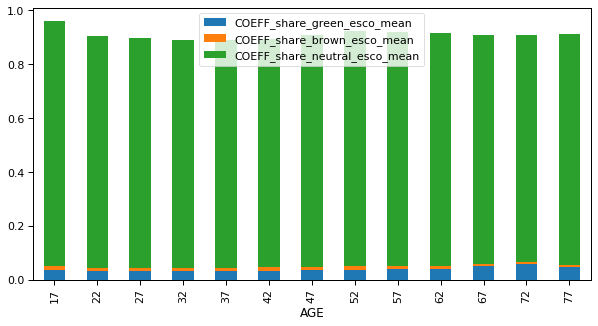

In [14]:
age_by_gbn_shares_rel.plot.bar(stacked=True, figsize=(10, 5))